In [1]:
import sys
sys.path.append("/vepfs-mlp2/c20250516/250504030/jing/InsightQMC")
from jkan.layers import RBFLayer, SineLayer
from jkan.models import KAN, MultKAN
from kan_wavefunction_case_one.kan_networks_case_one import make_kan_net_layers
import jax.numpy as jnp
import jax
import optax
from flax import nnx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

E0422 15:12:46.542254   14370 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0422 15:12:46.542333   14371 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0422 15:12:46.542364   14372 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


In [2]:
def f(x,y):
    return x**2 + 2*jnp.exp(y)

def generate_data(minval=-1, maxval=1, num_samples=1000, seed=42):
    key = jax.random.PRNGKey(seed)
    x_key, y_key = jax.random.split(key)

    x1 = jax.random.uniform(x_key, shape=(num_samples,), minval=minval, maxval=maxval)
    x2 = jax.random.uniform(y_key, shape=(num_samples,), minval=minval, maxval=maxval)

    y = f(x1, x2).reshape(-1, 1)
    X = jnp.stack([x1, x2], axis=1)
    
    return X, y

In [3]:
seed = 42

X, y = generate_data(minval=-1, maxval=1, num_samples=1000, seed=seed)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (800, 2)
Test set size: (200, 2)


In [5]:
# Initialize a KAN model
n_in = X_train.shape[1]
n_out = y_train.shape[1]
n_hidden = 6

layer_dims = [n_in, n_hidden, n_hidden, n_out]
req_params = {'D': 5, 'flavor': 'exact'}

model = KAN(layer_dims = layer_dims,
            layer_type = 'chebyshev',
            required_parameters = req_params,
            seed = 42
           )
# print(model)

In [6]:
opt_type = optax.adam(learning_rate=0.001)

optimizer_kan = nnx.Optimizer(model, opt_type, wrt=nnx.Param)

In [7]:
# Define train loop
@nnx.jit
def train_step(model, optimizer, X_train, y_train):

    def loss_fn(model):
        residual = model(X_train) - y_train
        loss = jnp.mean((residual)**2)

        return loss
    
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    
    return loss

In [8]:
# Initialize train_losses for KAN
num_epochs = 2000
train_losses_kan = jnp.zeros((num_epochs,))

for epoch in range(num_epochs):
    loss = train_step(model, optimizer_kan, X_train, y_train)
    train_losses_kan = train_losses_kan.at[epoch].set(loss)


W0422 15:12:53.689823   14390 autotuner.cc:601] No reference output found even though buffer checking was requested while autotuning
W0422 15:12:53.750502   14487 autotuner.cc:601] No reference output found even though buffer checking was requested while autotuning
W0422 15:12:53.752248   14403 autotuner.cc:601] No reference output found even though buffer checking was requested while autotuning
W0422 15:12:53.899863   14469 autotuner.cc:601] No reference output found even though buffer checking was requested while autotuning
W0422 15:12:53.931508   14457 autotuner.cc:601] No reference output found even though buffer checking was requested while autotuning


In [9]:
# Initialize a KAN model
n_in = X_train.shape[1]
n_out = y_train.shape[1]
n_hidden = 6

layer_dims = [n_in, [n_hidden, n_hidden], n_out]
req_params = {'D': 5, 'flavor': 'exact'}

mkan = MultKAN(width = layer_dims,
            layer_type = 'chebyshev',
            required_parameters = req_params,
            seed = 42
           )
# print(mkan)

In [10]:
opt_type = optax.adam(learning_rate=0.001)

optimizer = nnx.Optimizer(mkan, opt_type, wrt=nnx.Param)

In [11]:
# Define train loop
@nnx.jit
def train_step(model, optimizer, X_train, y_train):

    def loss_fn(model):
        residual = model(X_train) - y_train
        loss = jnp.mean((residual)**2)

        return loss
    
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    
    return loss

# Initialize train_losses for MultKAN
num_epochs = 2000
train_losses_mkan = jnp.zeros((num_epochs,))

for epoch in range(num_epochs):
    loss = train_step(mkan, optimizer, X_train, y_train)
    train_losses_mkan = train_losses_mkan.at[epoch].set(loss)



W0422 15:13:00.391365   14436 autotuner.cc:601] No reference output found even though buffer checking was requested while autotuning
E0422 15:13:00.588193   14391 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.9 = f32[18,10]{1,0} fusion(model_states_0__14_.1, bitcast.481, bitcast.470), kind=kCustom, calls=gemm_fusion_dot_general.9_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0422 15:13:00.588370   14391 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.9_computation.clone {
  parameter_0.1 = f32[18]{0} parameter(0)
  broadcast.107 = f32[800,18]{0,1} broadcast(parameter_0.1), dimensions={1}
  parame

In [12]:
# Train a functional KAN built with the same layer factory used inside make_kan_net
kan_net_layer_dims = jnp.array([n_in, n_hidden, n_hidden, n_out])
kan_net_g = jnp.array([5] * (len(kan_net_layer_dims) - 1))
kan_net_k = jnp.array([5] * (len(kan_net_layer_dims) - 1))
kan_net_grid_range = jnp.tile(jnp.array([[-1.0, 1.0]]), (len(kan_net_layer_dims) - 1, 1))

make_net_layers_init, make_net_layers_apply = make_kan_net_layers(
    layer_dims=kan_net_layer_dims,
    g=kan_net_g,
    k=kan_net_k,
    chebyshev=True,
    spline=False,
    add_residual=False,
    add_bias=True,
    external_weights=True,
)

make_net_params, make_net_output_dims = make_net_layers_init(jax.random.PRNGKey(seed))
print("make_kan_net_layers output dims:", make_net_output_dims)

optimizer_make_net = optax.adam(learning_rate=0.001)
make_net_opt_state = optimizer_make_net.init(make_net_params)

@jax.jit
def train_step_make_net(params, opt_state, X_train, y_train):
    def loss_fn(params):
        y_pred = make_net_layers_apply(params, X_train, grid_range=kan_net_grid_range)
        residual = y_pred - y_train
        return jnp.mean(residual**2)

    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer_make_net.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

train_losses_make_net = jnp.zeros((num_epochs,))

for epoch in range(num_epochs):
    make_net_params, make_net_opt_state, loss = train_step_make_net(
        make_net_params, make_net_opt_state, X_train, y_train
    )
    train_losses_make_net = train_losses_make_net.at[epoch].set(loss)


make_kan_net_layers output dims: 1


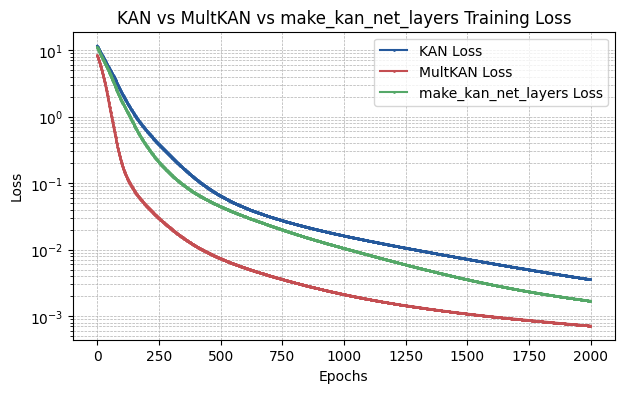

In [13]:
plt.figure(figsize=(7, 4))

plt.plot(
    np.array(train_losses_kan),
    label='KAN Loss',
    marker='o',
    color='#25599c',
    markersize=1,
)

plt.plot(
    np.array(train_losses_mkan),
    label='MultKAN Loss',
    marker='o',
    color='#c44e52',
    markersize=1,
)

plt.plot(
    np.array(train_losses_make_net),
    label='make_kan_net_layers Loss',
    marker='o',
    color='#55a868',
    markersize=1,
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('KAN vs MultKAN vs make_kan_net_layers Training Loss')
plt.yscale('log')

plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()



W0422 15:13:12.756326   14389 autotuner.cc:601] No reference output found even though buffer checking was requested while autotuning
W0422 15:13:13.480454   14389 autotuner.cc:601] No reference output found even though buffer checking was requested while autotuning
W0422 15:13:13.898646   14389 autotuner.cc:601] No reference output found even though buffer checking was requested while autotuning


KAN test MSE: 0.00562
MultKAN test MSE: 0.00107
make_kan_net_layers test MSE: 0.00348


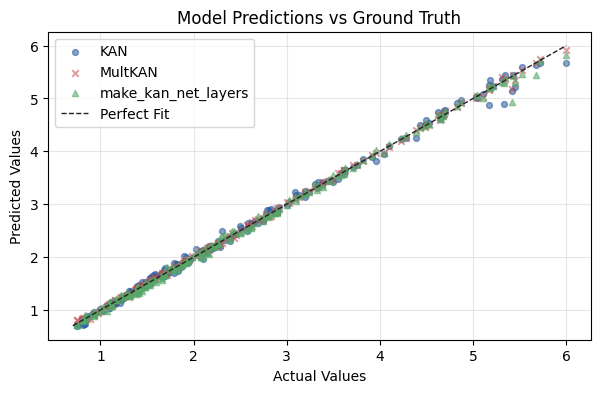

In [14]:
y_pred_kan = model(X_test)
y_pred_mkan = mkan(X_test)
y_pred_make_net = make_net_layers_apply(make_net_params, X_test, grid_range=kan_net_grid_range)

mse_kan = mean_squared_error(y_test, y_pred_kan)
mse_mkan = mean_squared_error(y_test, y_pred_mkan)
mse_make_net = mean_squared_error(y_test, y_pred_make_net)

print(f"KAN test MSE: {mse_kan:.5f}")
print(f"MultKAN test MSE: {mse_mkan:.5f}")
print(f"make_kan_net_layers test MSE: {mse_make_net:.5f}")

plt.figure(figsize=(7, 4))
plt.scatter(y_test, y_pred_kan, alpha=0.55, color="#25599c", marker="o", s=18, label="KAN")
plt.scatter(y_test, y_pred_mkan, alpha=0.55, color="#c44e52", marker="x", s=22, label="MultKAN")
plt.scatter(
    y_test,
    y_pred_make_net,
    alpha=0.55,
    color="#55a868",
    marker="^",
    s=20,
    label="make_kan_net_layers",
)

plot_values = jnp.concatenate([y_test.ravel(), y_pred_kan.ravel(), y_pred_mkan.ravel(), y_pred_make_net.ravel()])
min_value = float(jnp.min(plot_values))
max_value = float(jnp.max(plot_values))
plt.plot([min_value, max_value], [min_value, max_value], color="#222222", linestyle="--", linewidth=1, label="Perfect Fit")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Model Predictions vs Ground Truth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import math

def g1(x):
    return x**2

def g2(x):
    return math.log(x)

x = [2, 4, 6, 8]

# g1
sum_after_g1 = sum(g1(i) for i in x)
g1_after_sum = g1(sum(x))

# g2
sum_after_g2 = sum(g2(i) for i in x)
g2_after_sum = g2(sum(x))

print("g1: 先计算再求和 =", sum_after_g1)
print("g1: 先求和再计算 =", g1_after_sum)

print("g2: 先计算再求和 =", sum_after_g2)
print("g2: 先求和再计算 =", g2_after_sum)